Analiza zachowań użytkowników w e-commerce

Analiza interakcji użytkowników w platformie e-commerce, obejmująca konwersję w lejku sprzedażowym oraz retencję.

In [14]:
from google.colab import auth
auth.authenticate_user()

from google.cloud import bigquery
client = bigquery.Client(project="ecommence-494513")

W tej części analizowany jest przebieg użytkownika przez kolejne etapy procesu zakupowego:
view → cart → purchase.

In [15]:
query = """
WITH user_events AS (
  SELECT
    user_id,
    MIN(CASE WHEN event_type = 'view' THEN event_time END) AS view_time,
    MIN(CASE WHEN event_type = 'cart' THEN event_time END) AS cart_time,
    MIN(CASE WHEN event_type = 'purchase' THEN event_time END) AS purchase_time
  FROM `ecommence-494513.ecommerce.clean_events`
  GROUP BY user_id
)

SELECT
  'View' AS stage,
  COUNTIF(view_time IS NOT NULL) AS users
FROM user_events

UNION ALL

SELECT
  'Cart',
  COUNTIF(cart_time IS NOT NULL AND cart_time > view_time)
FROM user_events

UNION ALL

SELECT
  'Purchase',
  COUNTIF(purchase_time IS NOT NULL AND purchase_time > cart_time)
FROM user_events
"""

df_funnel = client.query(query).to_dataframe()
df_funnel

,stage,users
0,Cart,336481
1,Purchase,167986
2,View,3021273


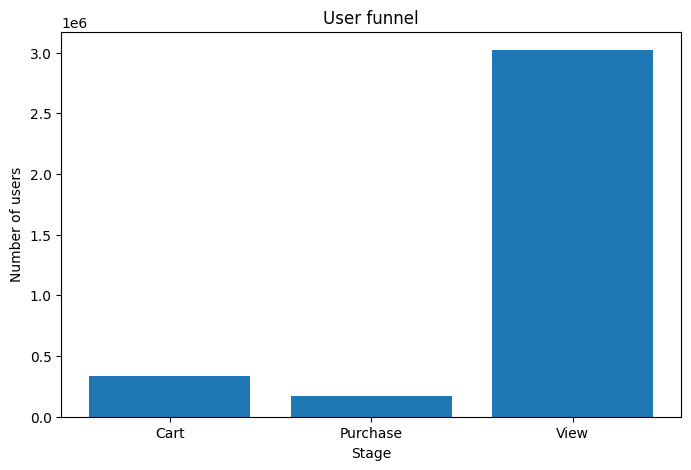

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(df_funnel['stage'], df_funnel['users'])

plt.title('User funnel')
plt.xlabel('Stage')
plt.ylabel('Number of users')

plt.show()

Wnioski: Największy spadek użytkowników występuje między etapem view a cart, co wskazuje na niską konwersję na wczesnym etapie ścieżki użytkownika.

Około 11% użytkowników przechodzi z przeglądania do dodania produktu do koszyka.

Konwersja z etapu cart do purchase (~50%) jest relatywnie wysoka, co sugeruje, że użytkownicy z intencją zakupu często finalizują transakcję.

Kluczowy obszar optymalizacji to etap view → cart, a nie proces zakupu.

Niżej: analiza retencji oparta jest na kohortach użytkowników, grupowanych według daty pierwszej interakcji.

Badane jest, ilu użytkowników wraca do platformy w kolejnych dniach od pierwszej wizyty.

In [17]:
query = """
WITH first_visit AS (
  SELECT
    user_id,
    MIN(DATE(event_time)) AS first_date
  FROM ecommerce.clean_events
  GROUP BY user_id
),

user_activity AS (
  SELECT
    e.user_id,
    DATE(e.event_time) AS activity_date,
    f.first_date,
    DATE_DIFF(DATE(e.event_time), f.first_date, DAY) AS days_since_first
  FROM ecommerce.clean_events e
  JOIN first_visit f
    ON e.user_id = f.user_id
),

cohort AS (
  SELECT
    first_date,
    days_since_first,
    COUNT(DISTINCT user_id) AS users
  FROM user_activity
  GROUP BY first_date, days_since_first
)

SELECT
  first_date,
  days_since_first,
  users,
  FIRST_VALUE(users) OVER (PARTITION BY first_date ORDER BY days_since_first) AS cohort_size,
  SAFE_DIVIDE(
    users,
    FIRST_VALUE(users) OVER (PARTITION BY first_date ORDER BY days_since_first)
  ) AS retention_rate
FROM cohort
ORDER BY first_date, days_since_first
"""

df = client.query(query).to_dataframe()
df.head()

,first_date,days_since_first,users,cohort_size,retention_rate
0,2019-10-01,0,190067,190067,1.000000
1,2019-10-01,1,32831,190067,0.172734
2,2019-10-01,2,25718,190067,0.135310
3,2019-10-01,3,27941,190067,0.147006
4,2019-10-01,4,23292,190067,0.122546


In [18]:
import pandas as pd

pivot = df.pivot_table(
    index='first_date',
    columns='days_since_first',
    values='retention_rate'
)

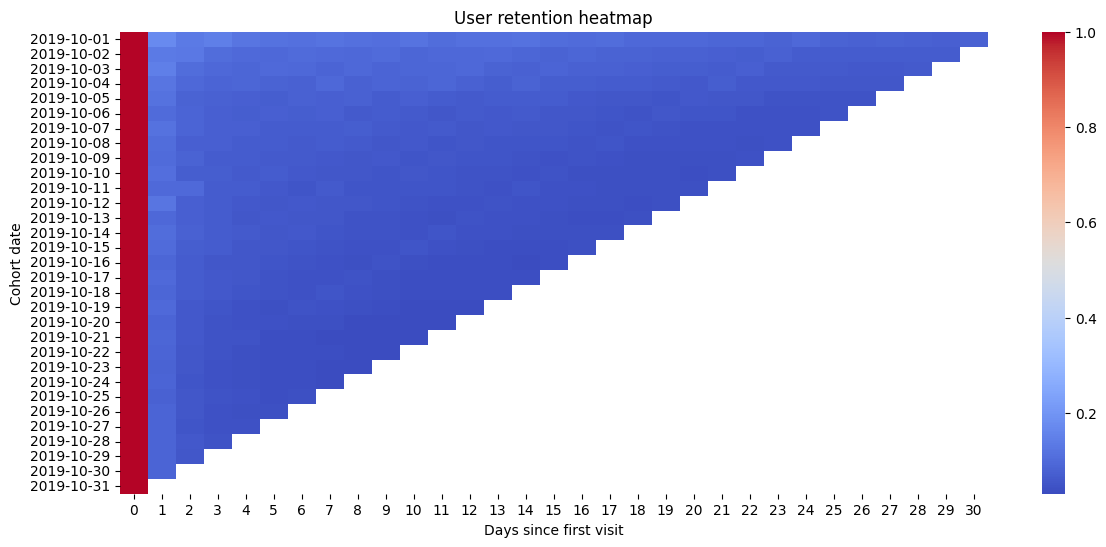

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14,6))

sns.heatmap(
    pivot,
    cmap="coolwarm",
    annot=False
)

plt.title('User retention heatmap')
plt.xlabel('Days since first visit')
plt.ylabel('Cohort date')

plt.show()

Wnioski:
1. Retencja użytkowników gwałtownie spada już po pierwszym dniu, co wskazuje na niski poziom zaangażowania po pierwszej interakcji.
2. W kolejnych dniach retencja stabilizuje się na niskim poziomie, co sugeruje brak długoterminowego zaangażowania użytkowników.
3. Brak wyraźnych różnic między kohortami może wskazywać na spójne, ale niskie doświadczenie użytkownika w czasie.

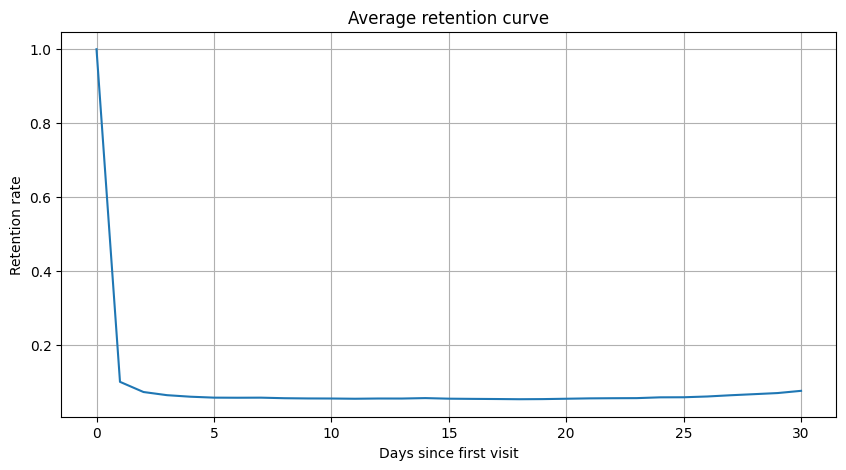

In [20]:
plt.figure(figsize=(10,5))
plt.plot(avg_retention.index, avg_retention.values)

plt.title('Average retention curve')
plt.xlabel('Days since first visit')
plt.ylabel('Retention rate')

plt.grid(True)
plt.show()

Wnioski:
Retencja użytkowników gwałtownie spada po pierwszym dniu (z ~100% do ok. 10%), co wskazuje na niski poziom powrotów po pierwszej interakcji.

Po 2–3 dniach retencja stabilizuje się na poziomie około 6–8%, co sugeruje istnienie niewielkiej grupy lojalnych użytkowników.

W dalszym okresie obserwowany jest niewielki wzrost retencji, co może wskazywać na powracających użytkowników dokonujących ponownych interakcji lub zakupów.

Ogólny trend wskazuje na słabe utrzymanie użytkowników w dłuższym okresie

In [21]:
plt.savefig('retention_heatmap.png')

<Figure size 640x480 with 0 Axes>

In [22]:
df.to_csv('retention.csv', index=False)
df_funnel.to_csv('funnel.csv', index=False)